In [190]:
import cv2
import numpy as np
import torch.utils.data as data
import torch
import torch.optim as optim
import torch.nn as nn
from torchsummary import summary
import os
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import json
import pandas as pd
import copy
from metrics import SSIM
from datasets import DenoiseDegradeDataset, NoiseEstimateDataset
from model_name import name_denoise_model, name_estimator_model
from enchaned_denoiser import *
from estimator import NoiseEstimator

from typing import Optional


np.random.seed(13)
torch.manual_seed(13)
torch.cuda.manual_seed(13)


In [191]:
DATASET_PATH = 'Div2K/'
PATH_TRAIN = DATASET_PATH + 'DIV2K_train_HR/'
PATH_TEST = DATASET_PATH + 'DIV2K_valid_HR/'
DENOISE_MODELS_PATH = 'denoise_models/'
ESTIMATOR_MODELS_PATH = 'estimator_models/'

In [192]:
all_files = sorted(os.listdir(PATH_TRAIN))
split_idx = int(len(all_files)*0.9)
train_files = all_files[:split_idx]
val_files = all_files[split_idx:]
test_files = sorted(os.listdir(PATH_TEST))

In [193]:
loaded = False

In [194]:
test_tensor = torch.rand(4, 64, 64, 64)

In [234]:
parameters = {
    'architecture': 'ED', # EnhancedDenoiser
    'noise_map': False, # True, False
    'loss': 'MSE', # MSE, L1
    'learning_rate': 0.0001,
    'patch_size': 128,
    'scale_factor': 2,
    'noise_level': None, # 15, 25, 50, None
    'num_blocks': 8,
    'attention': 'CBAM', # CBAM, Channel, Spatial, None
    'reduction': 8,
    'dilation': 2,  # 1, 2
    'res_scale': 1, # 0.1, 1
    'early_stopping': False # True, False
}

In [196]:
model_name = name_denoise_model(*parameters.values())

In [197]:
model_name

'ED_MSE_lr1e-04_ps128_sf2_nNone_nb8_CBAM(r8)_d2'

In [198]:
if 'denoise_models' not in os.listdir('./'):
        os.mkdir('denoise_models')

In [199]:
if 'estimator_models' not in os.listdir('./'):
        os.mkdir('estimator_models')

In [200]:
if model_name in os.listdir(DENOISE_MODELS_PATH) and not loaded:
    raise FileExistsError
elif model_name not in os.listdir(DENOISE_MODELS_PATH) and loaded:
    raise FileNotFoundError

In [201]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [202]:
estimator = None

In [203]:
if parameters['noise_level'] is None and parameters['noise_map']:
    estimator_name = name_estimator_model(parameters['patch_size'], parameters['scale_factor'])
    if estimator_name not in os.listdir(ESTIMATOR_MODELS_PATH):
        estimator_loaded = False
        estimator_set = NoiseEstimateDataset(PATH_TRAIN, all_files, parameters['patch_size'], parameters['scale_factor'], None)
        estimator_loader = data.DataLoader(estimator_set, batch_size=1, shuffle=True)
        estimator = NoiseEstimator().to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(estimator.parameters(), lr=0.0001)
        
        loss_list = []
        for epoch in range(20):
            estimator.train()
            epoch_loss = 0 
            
            for pair in estimator_loader:
                noisy_lr, target = pair[0].to(device), pair[1].to(device)
                output = estimator(noisy_lr)
                optimizer.zero_grad()
                loss = criterion(output, target)
                loss.backward()
                optimizer.step()
                
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / len(estimator_loader)
            loss_list.append(avg_loss)
            print(f'Epoch: {epoch + 1}, Train loss: {avg_loss}')
        
        os.mkdir(ESTIMATOR_MODELS_PATH + estimator_name)
        torch.save(estimator, ESTIMATOR_MODELS_PATH + estimator_name + '/model.pth')
    else:
        estimator_loaded = True
        estimator = torch.load(ESTIMATOR_MODELS_PATH + estimator_name + '/model.pth', weights_only=False)
    
                
        

In [204]:
train_set = DenoiseDegradeDataset(PATH_TRAIN, train_files, parameters['patch_size'], parameters['scale_factor'], parameters['noise_level'], use_noise_map=parameters['noise_map'], estimate_model=estimator)
if parameters['noise_level'] is None:
    val_noise = 15
else:
    val_noise = parameters['noise_level']
val_set = DenoiseDegradeDataset(PATH_TRAIN, val_files, parameters['patch_size'], parameters['scale_factor'], val_noise, use_noise_map=parameters['noise_map'])

test_set = DenoiseDegradeDataset(PATH_TEST, test_files, parameters['patch_size'], parameters['scale_factor'], val_noise, use_augm=False, use_noise_map=parameters['noise_map'])

full_set = DenoiseDegradeDataset(PATH_TEST, test_files, None, parameters['scale_factor'], val_noise, use_augm=False, use_noise_map=parameters['noise_map'])

In [205]:
train_loader = data.DataLoader(train_set, batch_size=4, shuffle=True)
val_loader = data.DataLoader(val_set, batch_size=8, shuffle=False)
test_loader = data.DataLoader(test_set, batch_size=1, shuffle=False)
full_set_loader = data.DataLoader(full_set, batch_size=1, shuffle=False)

In [206]:
if parameters['noise_level'] is None and parameters['noise_map']:
	if not estimator_loaded:
		df = pd.DataFrame({'MSE': loss_list})
		df.to_csv(ESTIMATOR_MODELS_PATH + estimator_name + '/train_metrics.csv', index=False)  
		iteration_list = list(range(1, 21))
		plt.plot(iteration_list, loss_list)
		
		plt.xlabel('Epochs')
		plt.ylabel('Loss')
		plt.title('MSE')
		plt.savefig(ESTIMATOR_MODELS_PATH + estimator_name + '/loss_fig.png')
		plt.show()

In [207]:
if parameters['noise_level'] is None and parameters['noise_map']:
	if not estimator_loaded:
		estimator_epoch_loss = 0
		estimator.eval()
		with torch.no_grad():
			for pair in test_loader:
				noisy_lr = pair[0][:, :3, :, :].to(device)
				output = estimator(noisy_lr)
				target_map = torch.full_like(pair[0][:, :1], val_noise / 255).to(device)
				loss = criterion(output, target_map)
				estimator_epoch_loss += loss.item()
				
		print(f'Loss on the {len(test_loader)} test images: {estimator_epoch_loss/len(test_loader)}')
		
		df = pd.DataFrame({'Loss': [estimator_epoch_loss/len(test_loader)]})
		df.to_csv(ESTIMATOR_MODELS_PATH + estimator_name + '/test_metrics.csv', index=False)  

In [208]:
class SimpleDenoiser(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, num_layers=17, num_filters=64):
        super().__init__()
        
        layers = []
        layers.append(nn.Conv2d(in_channels, num_filters, kernel_size=3, padding=1))
        layers.append(nn.ReLU(inplace=True))
        
        for _ in range(num_layers - 2):
            layers.append(nn.Conv2d(num_filters, num_filters, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(num_filters))
            layers.append(nn.ReLU(inplace=True))
        
        layers.append(nn.Conv2d(num_filters, out_channels, kernel_size=3, padding=1))
        
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        noise = self.net(x)
        return x - noise

In [209]:
# att = ChannelAttention(64, 8)
# att(test_tensor)

In [210]:
if parameters['noise_map'] == True:
    channels = 4
else:
    channels = 3

In [211]:
# model = SimpleDenoiser()
model = EnhancedDenoiser(in_channels=channels, num_blocks=parameters['num_blocks'], reduction=parameters['reduction'], dilation=parameters['dilation'], res_scale=parameters['res_scale'])
model.to(device)


EnhancedDenoiser(
  (head): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (body): Sequential(
    (0): DenoiseResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (channel_attention): ChannelAttention(
        (avg_pool): AdaptiveAvgPool2d(output_size=1)
        (max_pool): AdaptiveMaxPool2d(output_size=1)
        (shared_mlp): Sequential(
          (0): Linear(in_features=64, out_features=8, bias=False)
          (1): ReLU(inplace=True)
          (2): Linear(in_features=8, out_features=64, bias=False)
          (3): Sigmoid()
        )
      )
      (spatial_attention): SpatialAttention(
        (conv): Conv2d(2, 1, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
        (sigmoid): Sigmoid()
      )
    )
    (1): DenoiseResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stri

In [212]:
summary(model)

Layer (type:depth-idx)                        Param #
├─Conv2d: 1-1                                 1,792
├─Sequential: 1-2                             --
|    └─DenoiseResidualBlock: 2-1              --
|    |    └─Conv2d: 3-1                       36,928
|    |    └─ReLU: 3-2                         --
|    |    └─Conv2d: 3-3                       36,928
|    |    └─ChannelAttention: 3-4             1,024
|    |    └─SpatialAttention: 3-5             98
|    └─DenoiseResidualBlock: 2-2              --
|    |    └─Conv2d: 3-6                       36,928
|    |    └─ReLU: 3-7                         --
|    |    └─Conv2d: 3-8                       36,928
|    |    └─ChannelAttention: 3-9             1,024
|    |    └─SpatialAttention: 3-10            98
|    └─DenoiseResidualBlock: 2-3              --
|    |    └─Conv2d: 3-11                      36,928
|    |    └─ReLU: 3-12                        --
|    |    └─Conv2d: 3-13                      36,928
|    |    └─ChannelAttention: 3

Layer (type:depth-idx)                        Param #
├─Conv2d: 1-1                                 1,792
├─Sequential: 1-2                             --
|    └─DenoiseResidualBlock: 2-1              --
|    |    └─Conv2d: 3-1                       36,928
|    |    └─ReLU: 3-2                         --
|    |    └─Conv2d: 3-3                       36,928
|    |    └─ChannelAttention: 3-4             1,024
|    |    └─SpatialAttention: 3-5             98
|    └─DenoiseResidualBlock: 2-2              --
|    |    └─Conv2d: 3-6                       36,928
|    |    └─ReLU: 3-7                         --
|    |    └─Conv2d: 3-8                       36,928
|    |    └─ChannelAttention: 3-9             1,024
|    |    └─SpatialAttention: 3-10            98
|    └─DenoiseResidualBlock: 2-3              --
|    |    └─Conv2d: 3-11                      36,928
|    |    └─ReLU: 3-12                        --
|    |    └─Conv2d: 3-13                      36,928
|    |    └─ChannelAttention: 3

In [213]:
criterion = nn.MSELoss()
if parameters['loss'] == 'MSE':
    criterion = nn.MSELoss()
elif parameters['loss'] == 'L1':
    criterion = nn.L1Loss()

optimizer = optim.Adam(model.parameters(), lr=parameters['learning_rate'])

In [214]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min', 
    factor=0.8, 
    patience=5,
)

In [215]:
best_loss = float('inf')
patience_counter = 0
early_model_state = 15
best_model_state = None
final_epoch = None

In [216]:
ssim = SSIM()

In [217]:
if not loaded:
    epochs = 100
    train_loss_list = []
    val_loss_list = []
    psnr_list = []
    ssim_list = []
    lr_list = []
    
    for epoch in range(epochs):
        model.train()
        total_epoch_train_loss = 0
        for pair in train_loader:
            
            noisy_lr, clean_lr = pair[0].to(device), pair[1].to(device)
            optimizer.zero_grad()

            output = model(noisy_lr)
            loss = criterion(output, clean_lr)
            loss.backward()
            optimizer.step()

            total_epoch_train_loss += loss.item()

        avg_train_loss = total_epoch_train_loss/len(train_loader)
        train_loss_list.append(avg_train_loss)
        lr_list.append(scheduler.get_last_lr()[0])

        model.eval()
        total_epoch_val_loss = 0
        total_epoch_val_psnr = 0
        total_epoch_val_ssim = 0
        with torch.no_grad():
            for pair in val_loader:
                noisy_lr, clean_lr = pair[0].to(device), pair[1].to(device)

                output = model(noisy_lr)
                loss = criterion(output, clean_lr)
        
                total_epoch_val_loss += loss.item()
                mse = torch.mean((output - clean_lr)**2, dim=[1, 2, 3])
                total_epoch_val_psnr += 10 * torch.log10(1/(mse+1e-10)).mean().item()
                
                total_epoch_val_ssim += ssim(output, clean_lr).item()

        avg_val_loss = total_epoch_val_loss / len(val_loader)
        avg_val_psnr = total_epoch_val_psnr / len(val_loader)
        avg_val_ssim = total_epoch_val_ssim / len(val_loader)
        
        val_loss_list.append(avg_val_loss)
        psnr_list.append(avg_val_psnr)
        ssim_list.append(avg_val_ssim)

        print(f'Epoch: {epoch + 1}, Train loss: {avg_train_loss}, Val loss: {avg_val_loss}, Val PSNR: {avg_val_psnr}, Val SSIM: {avg_val_ssim}, Learning rate: {scheduler.get_last_lr()[0]}')

        scheduler.step(avg_val_loss)
        if parameters['early_stopping']:
            if avg_val_loss < best_loss:
                best_loss = avg_val_loss
                patience_counter = 0
                best_model_state = copy.deepcopy(model.state_dict()) # ?
                final_epoch = epoch

            else:
                patience_counter += 1
                if early_model_state == patience_counter:
                    epoch = final_epoch
                    model.load_state_dict(best_model_state)
                    break

Epoch: 1, Train loss: 0.007989149557478313, Val loss: 0.001713983912486583, Val PSNR: 28.40076732635498, Val SSIM: 0.8230203628540039, Learning rate: 0.0001
Epoch: 2, Train loss: 0.0032965958719917885, Val loss: 0.0015764655603561551, Val PSNR: 29.01193857192993, Val SSIM: 0.8428988933563233, Learning rate: 0.0001
Epoch: 3, Train loss: 0.003094097927937077, Val loss: 0.0015112745924852789, Val PSNR: 29.358855962753296, Val SSIM: 0.8358707308769227, Learning rate: 0.0001
Epoch: 4, Train loss: 0.0029627212970000172, Val loss: 0.0013983820681460202, Val PSNR: 29.49533438682556, Val SSIM: 0.8492212653160095, Learning rate: 0.0001
Epoch: 5, Train loss: 0.002796909976233211, Val loss: 0.001328765763901174, Val PSNR: 29.906280517578125, Val SSIM: 0.8558597505092621, Learning rate: 0.0001
Epoch: 6, Train loss: 0.0026506326145156185, Val loss: 0.001351296523353085, Val PSNR: 30.308437824249268, Val SSIM: 0.867790800333023, Learning rate: 0.0001
Epoch: 7, Train loss: 0.0025545614402896414, Val l

In [218]:
if model_name not in os.listdir(DENOISE_MODELS_PATH) and not loaded:
    os.mkdir(DENOISE_MODELS_PATH + model_name)

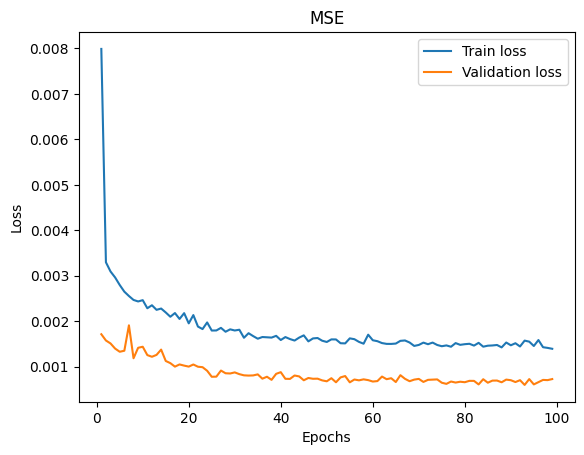

In [219]:
if not loaded:
    iteration_list = list(range(1, epoch+1))
    df = pd.DataFrame({'train_loss': train_loss_list, 'val_loss': val_loss_list, 'val_psnr': psnr_list,'lr': lr_list})
    df.to_csv(f'{DENOISE_MODELS_PATH + model_name}/metrics.csv', index=False)  
    plt.plot(iteration_list, train_loss_list[:epoch])
    plt.plot(iteration_list, val_loss_list[:epoch])
    plt.legend(['Train loss','Validation loss'])
    
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(parameters['loss'])
    plt.savefig(f'{DENOISE_MODELS_PATH}/{model_name}/loss_fig.png')
    plt.show()

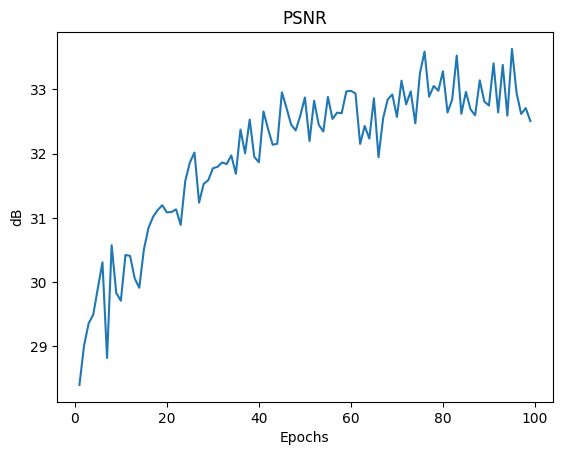

In [220]:
if not loaded:
    plt.plot(iteration_list, psnr_list[:epoch])
    plt.xlabel('Epochs')
    plt.ylabel('dB')
    plt.title('PSNR')
    plt.savefig(f'{DENOISE_MODELS_PATH}/{model_name}/psnr_fig.png')
    plt.show()

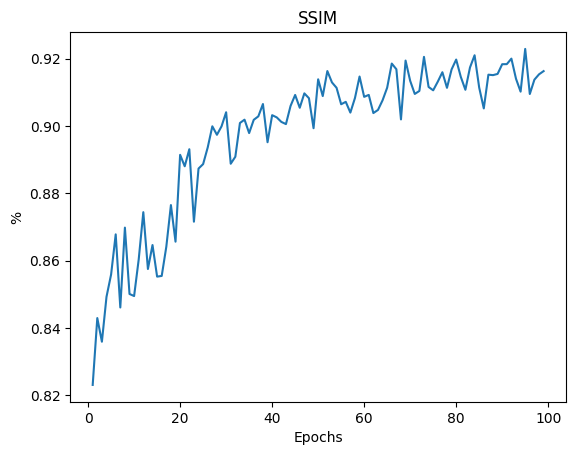

In [221]:
if not loaded:
    plt.plot(iteration_list, ssim_list[:epoch])
    plt.xlabel('Epochs')
    plt.ylabel('%')
    plt.title('SSIM')
    plt.savefig(f'{DENOISE_MODELS_PATH}/{model_name}/ssim_fig.png')
    plt.show()

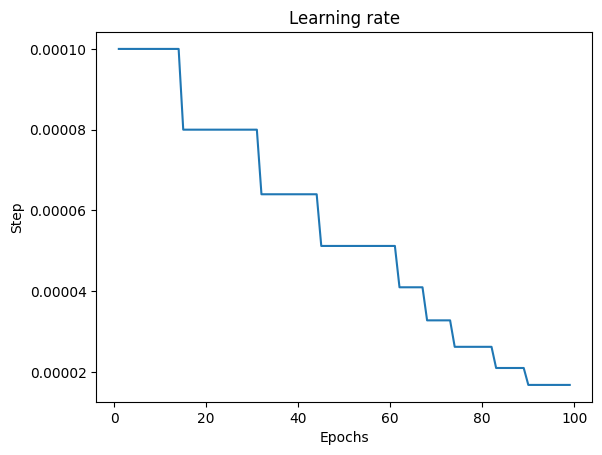

In [222]:
if not loaded:
    plt.plot(iteration_list, lr_list[:epoch])
    plt.xlabel('Epochs')
    plt.ylabel('Step')
    plt.title('Learning rate')
    plt.savefig(f'{DENOISE_MODELS_PATH}/{model_name}/lr_fig.png')
    plt.show()

In [ ]:
if loaded:
    model = torch.load(f'{DENOISE_MODELS_PATH}/{model_name}/model.pth', weights_only=False)
    

In [224]:
test_epoch_loss = 0
test_epoch_psnr = 0
test_epoch_ssim = 0

model.eval()
with torch.no_grad():
    for pair in test_loader:
        noisy_lr, clean_lr = pair[0].to(device), pair[1].to(device)
                        
        output = model(noisy_lr)
        loss = criterion(output, clean_lr)
        mse = torch.mean((output - clean_lr)**2, dim=[1, 2, 3])
        
        test_epoch_loss += loss.item()
        test_epoch_psnr += 10 * torch.log10(1/(mse+1e-10)).mean().item()
        
        test_epoch_ssim += ssim(output, clean_lr).item()

print(f'Loss on the {len(test_loader)} test images: {test_epoch_loss/len(test_loader)}')
print(f'PSNR on the {len(test_loader)} test images: {test_epoch_psnr/len(test_loader)}')
print(f'PSNR on the {len(test_loader)} test images: {test_epoch_ssim/len(test_loader)}')



Loss on the 100 test images: 0.0006804399522661697
PSNR on the 100 test images: 32.770931243896484
PSNR on the 100 test images: 0.9239127379655838


In [225]:
test_epoch_psnr/len(test_loader)

32.770931243896484

In [226]:
test_epoch_loss/len(test_loader)

0.0006804399522661697

In [227]:
sum(p.numel() for p in model.parameters())

603347

In [228]:
if not loaded:
    df = pd.DataFrame({'PSNR': [test_epoch_psnr/len(test_loader)],
                   'loss': [test_epoch_loss/len(test_loader)],
                   'SSIM': [test_epoch_ssim/len(test_loader)],
                   'params': [sum(p.numel() for p in model.parameters())],
                   'final_epoch': [epoch]})
    df.to_csv(f'{DENOISE_MODELS_PATH}/{model_name}/test_metrics.csv', index=False)  

    torch.save(model, f'{DENOISE_MODELS_PATH}/{model_name}/model.pth')
    
    with open(f'{DENOISE_MODELS_PATH}/{model_name}/config.json', 'w', encoding='utf-8') as f:
        json.dump(parameters, f, indent=4, ensure_ascii=False)

In [229]:

# if loaded:
#     noisy, clean = next(iter(full_set_loader))
# else:
noisy, clean = next(iter(test_loader))


In [230]:
with torch.no_grad():
    noisy_cuda = noisy.to(device)
    out = model(noisy_cuda)

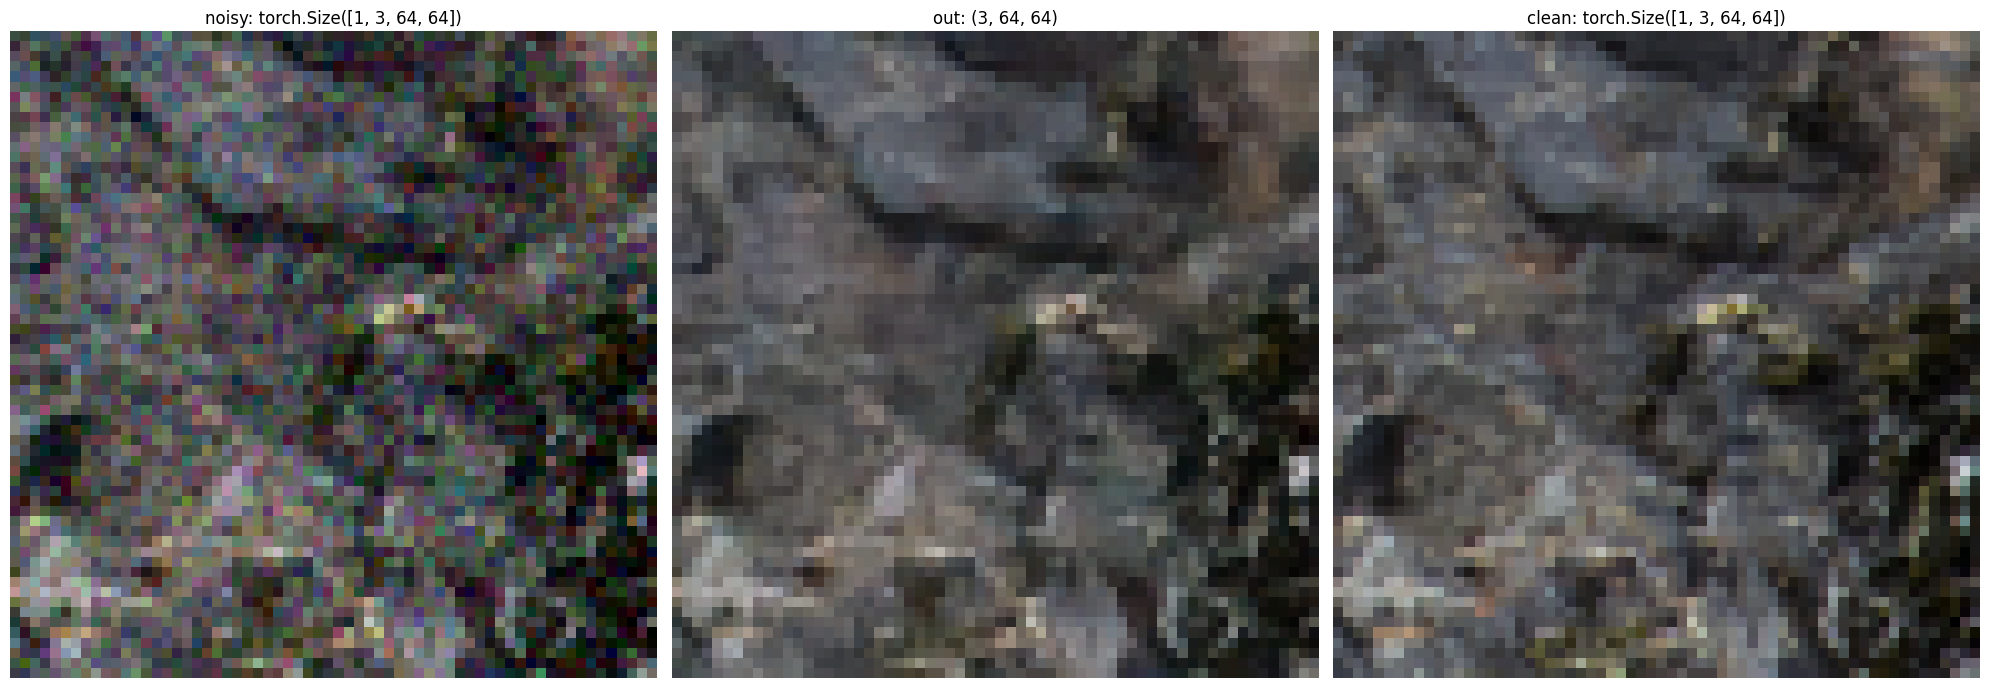

In [232]:
fig, axes = plt.subplots(1, 3, figsize=(20, 15))

axes[0].imshow(np.transpose(noisy[0][:3, :, :], (1, 2, 0)))
axes[0].set_title(f"noisy: {noisy.shape}")
axes[0].axis('off')

axes[1].imshow(np.transpose(out.cpu().data.numpy()[0], (1, 2, 0)))
axes[1].set_title(f"out: {out.cpu().data.numpy()[0].shape}")
axes[1].axis('off')


axes[2].imshow(np.transpose(clean[0], (1, 2, 0)))
axes[2].set_title(f"clean: {clean.shape}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [233]:
import plyer
plyer.notification.notify(
    message='Всё',
    title=model_name, )